# Taller 06 - Reducción de Dimensiones
**Inteligencia Artificial - ELP 8012 - Universidad del Norte**  
**Programa de Ingeniería de Sistemas**  
**Profesor: Eduardo Zurek, Ph.D.**

| grupo15 |
|---|
| Galvis Pajaro, Carlos |
| Molina Vega, Dayana |
| Romero Pemberthy, Juan |

## Objetivo
Usar el dataset **WISDM** (acelerómetro y giroscopio de teléfono y reloj) y proyectar a **2D** con **PCA**, **MDS clásico**, **MDS métrico**, **MDS no-métrico** y **UMAP**, coloreando por `ACTIVITY`.


## 1. Librerías

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
from pathlib import Path
from urllib.request import urlretrieve

from sklearn.decomposition import PCA
from sklearn.manifold import ClassicalMDS, MDS
import umap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (14, 3.2)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25


## 2. Datos WISDM y selección de sujetos

Se eligen **3 voluntarios al azar** entre 1600-1650 (sin 1614).  
Características usadas: bins `X0…X9`, `Y0…Y9`, `Z0…Z9`. Etiqueta: `ACTIVITY`.


In [2]:
DATA_DIR = Path("data/arff")
DATA_DIR.mkdir(parents=True, exist_ok=True)

BASE_URL = "https://raw.githubusercontent.com/mnnguyen2/WISDM/master/arff_python"

CASES = {
    "phone-accel": "accel_phone",
    "phone-gyro": "gyro_phone",
    "watch-accel": "accel_watch",
    "watch-gyro": "gyro_watch",
}

XYZBINS = [f"{axis}{i}" for axis in "XYZ" for i in range(10)]

ACTIVITY_NAMES = {
    "A": "Walking", "B": "Jogging", "C": "Stairs", "D": "Sitting", "E": "Standing",
    "F": "Typing", "G": "Brushing teeth", "H": "Eating soup", "I": "Eating chips",
    "J": "Eating pasta", "K": "Drinking", "L": "Eating sandwich", "M": "Kicking ball",
    "O": "Playing catch", "P": "Dribbling", "Q": "Writing", "R": "Clapping",
    "S": "Folding clothes",
}

subjects_pool = [i for i in range(1600, 1651) if i != 1614]
SUBJECTS = sorted(
    np.random.default_rng(RANDOM_STATE).choice(subjects_pool, size=3, replace=False).tolist()
)
print("Sujetos seleccionados:", SUBJECTS)


def ensure_arff(subject_id, suffix):
    fname = f"data_{subject_id}_{suffix}.arff"
    path = DATA_DIR / fname
    if not path.exists():
        print(f"Descargando {fname}...")
        urlretrieve(f"{BASE_URL}/{fname}", path)
    return path


for sid in SUBJECTS:
    for suffix in CASES.values():
        ensure_arff(sid, suffix)

print("Archivos listos en", DATA_DIR.resolve())


Sujetos seleccionados: [1604, 1633, 1638]
Archivos listos en C:\Users\Cgalv\Desktop\AI_talleres\taller06\data\arff


## 3. Funciones auxiliares

In [3]:
def load_sample(subject_id, suffix):
    """Carga ARFF y retorna matriz xyzbins + ACTIVITY."""
    path = ensure_arff(subject_id, suffix)
    data, _ = sp.io.arff.loadarff(path)
    df = pd.DataFrame(data)
    df.columns = df.columns.str.replace('"', "", regex=False)
    df["ACTIVITY"] = df["ACTIVITY"].apply(
        lambda x: x.decode("utf-8") if isinstance(x, bytes) else x
    )
    X = df[XYZBINS].astype(float).values
    y = df["ACTIVITY"].astype(str).values
    return X, y


def reduce_2d(X):
    """Aplica las 5 técnicas de reducción a 2D."""
    embeddings = {}
    embeddings["PCA"] = PCA(n_components=2).fit_transform(X)
    embeddings["MDS Clásico"] = ClassicalMDS(n_components=2).fit_transform(X)
    embeddings["MDS Métrico"] = MDS(
        n_components=2,
        metric_mds=True,
        n_init=1,
        max_iter=150,
        random_state=RANDOM_STATE,
        normalized_stress="auto",
    ).fit_transform(X)
    embeddings["MDS No-métrico"] = MDS(
        n_components=2,
        metric_mds=False,
        n_init=1,
        max_iter=150,
        random_state=RANDOM_STATE,
        normalized_stress="auto",
    ).fit_transform(X)
    embeddings["UMAP"] = umap.UMAP(
        n_components=2, random_state=RANDOM_STATE, n_jobs=1
    ).fit_transform(X)
    return embeddings


def plot_embeddings(embeddings, y, title):
    labels = np.unique(y)
    base = plt.colormaps["tab20"]
    colors = [base(i % 20) for i in range(len(labels))]
    fig, axes = plt.subplots(1, 5, figsize=(16, 3.4))
    fig.suptitle(title, fontsize=12, y=1.02)

    for ax, (name, Z) in zip(axes, embeddings.items()):
        for i, lab in enumerate(labels):
            mask = y == lab
            ax.scatter(
                Z[mask, 0],
                Z[mask, 1],
                s=12,
                alpha=0.75,
                color=colors[i],
                label=f"{lab}:{ACTIVITY_NAMES.get(lab, lab)}",
            )
        ax.set_title(name, fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])

    handles, labels_leg = axes[-1].get_legend_handles_labels()
    fig.legend(
        handles,
        labels_leg,
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        fontsize=7,
        frameon=False,
        markerscale=1.4,
    )
    plt.tight_layout()
    plt.show()


## 4. Reducción por sujeto

Para cada voluntario y cada sensor (`phone-accel`, `phone-gyro`, `watch-accel`, `watch-gyro`) se proyecta a 2D con las cinco técnicas.


Sujeto 1604
phone-accel: 321 ejemplos, 30 features, 18 actividades


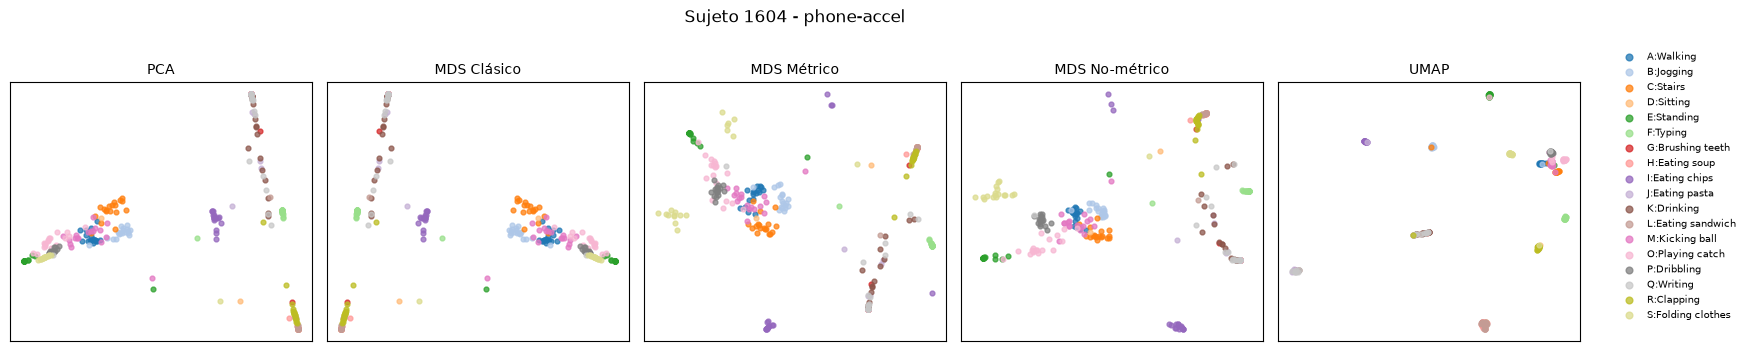

phone-gyro: 321 ejemplos, 30 features, 18 actividades


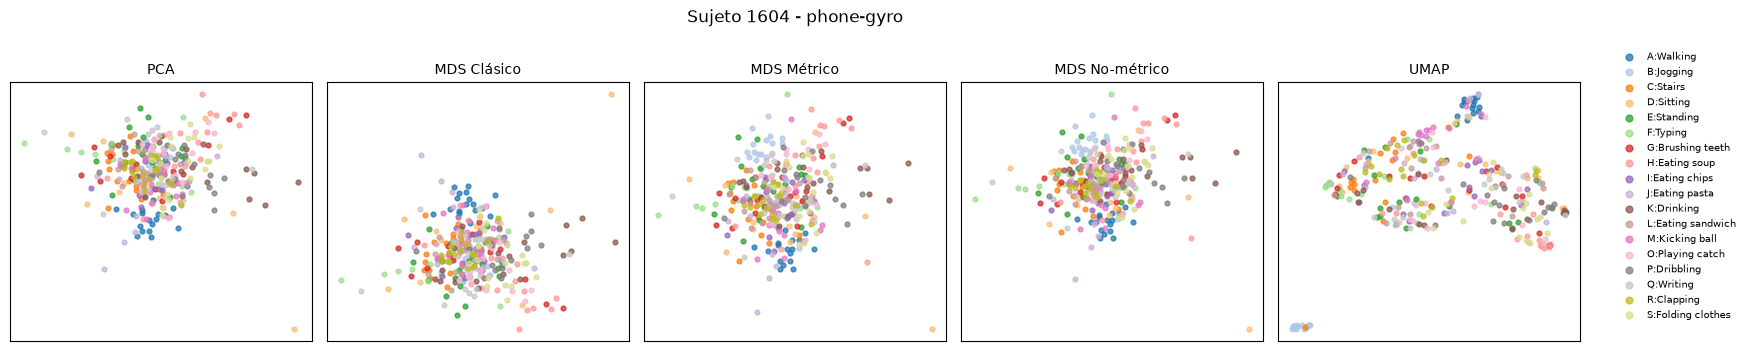

watch-accel: 324 ejemplos, 30 features, 18 actividades


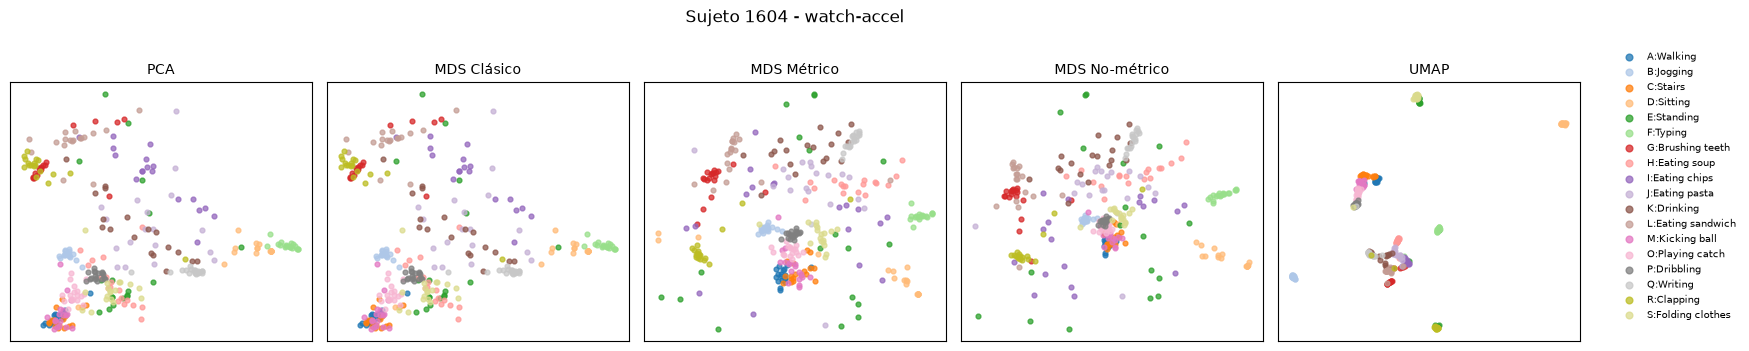

watch-gyro: 324 ejemplos, 30 features, 18 actividades


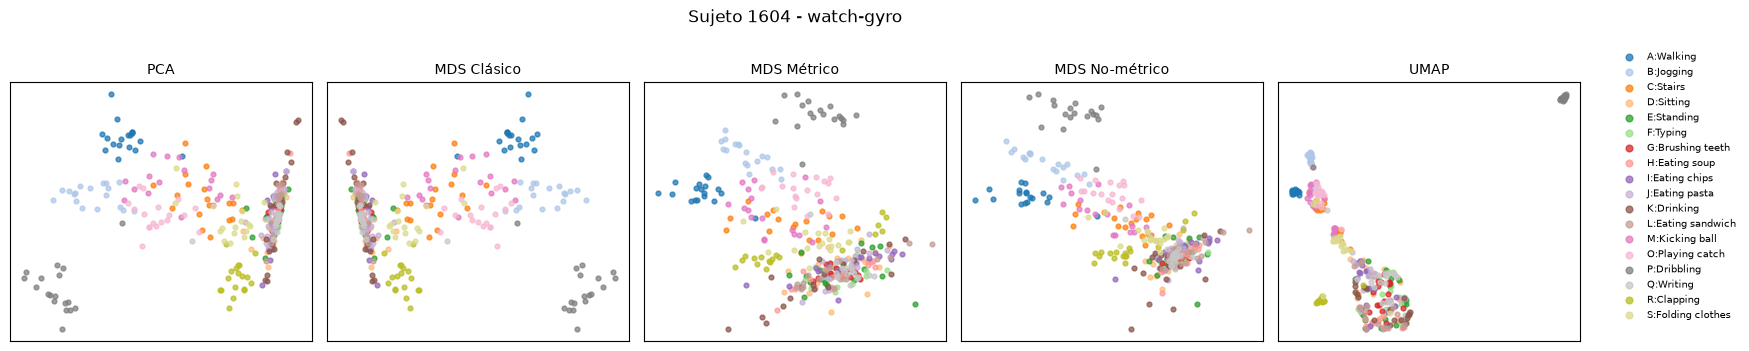

Sujeto 1633
phone-accel: 429 ejemplos, 30 features, 18 actividades


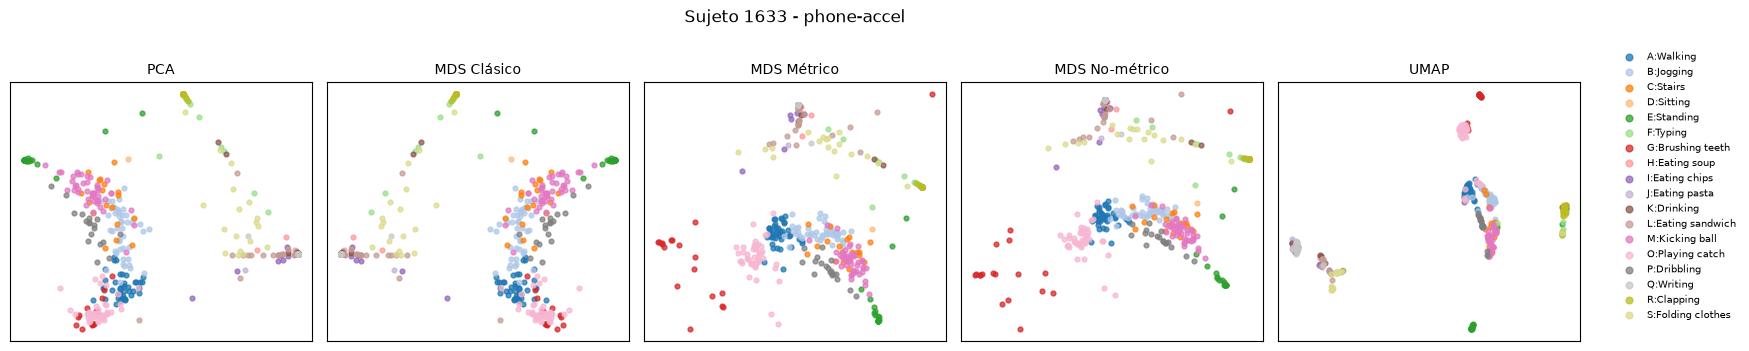

phone-gyro: 321 ejemplos, 30 features, 18 actividades


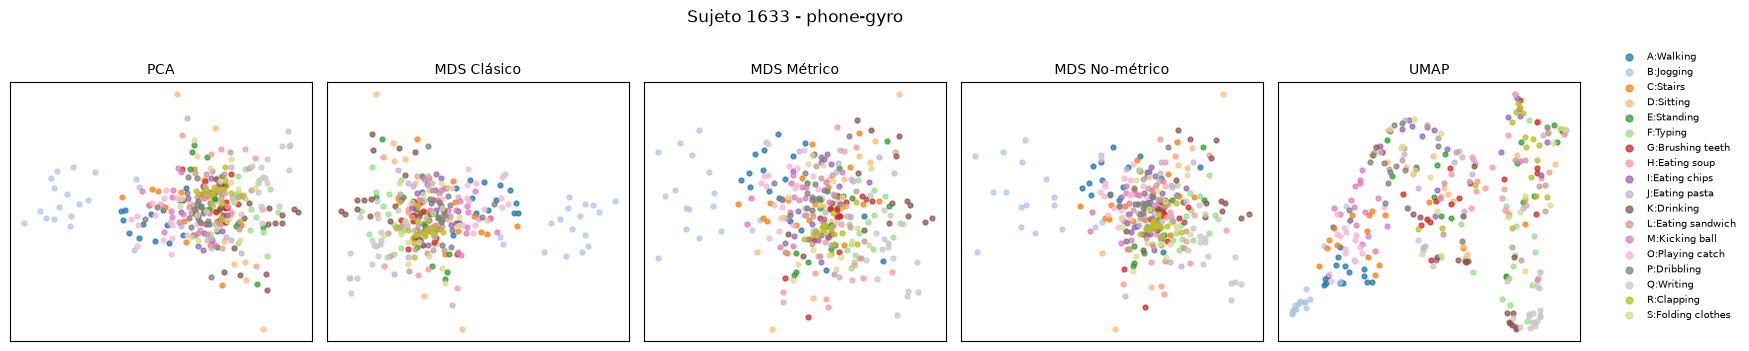

watch-accel: 324 ejemplos, 30 features, 18 actividades


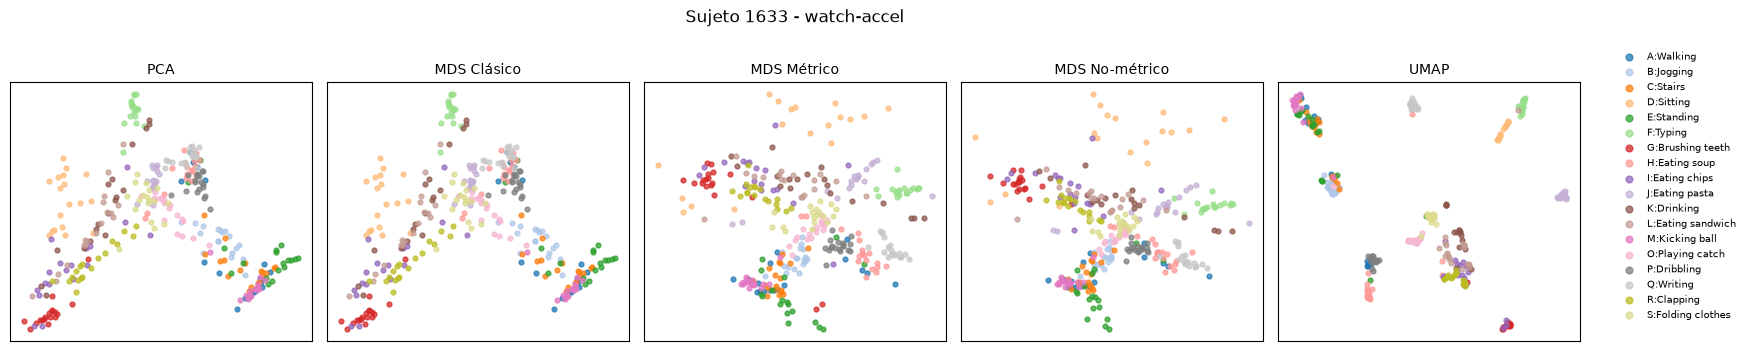

watch-gyro: 324 ejemplos, 30 features, 18 actividades


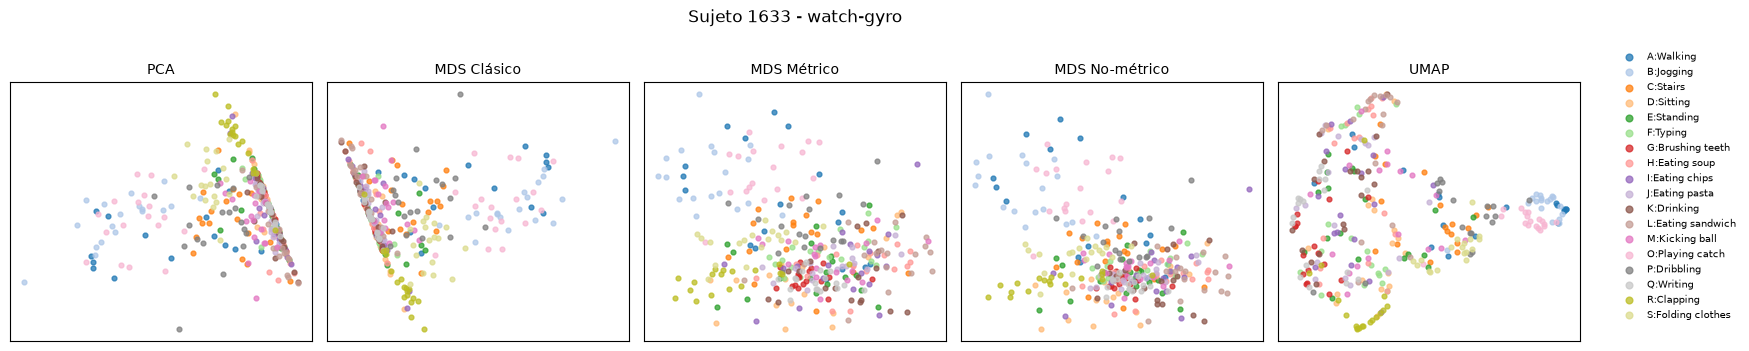

Sujeto 1638
phone-accel: 324 ejemplos, 30 features, 18 actividades


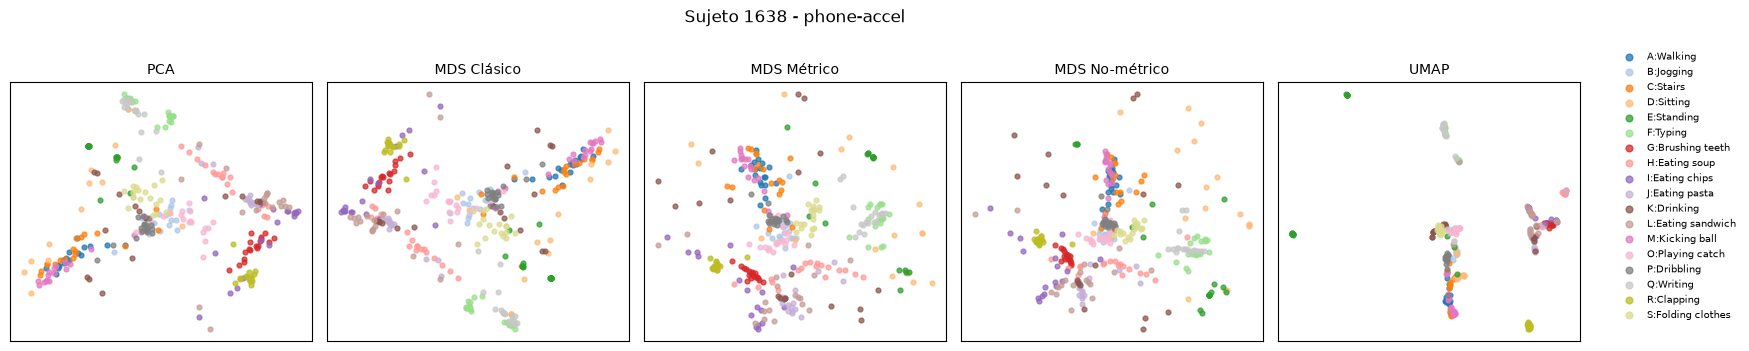

phone-gyro: 323 ejemplos, 30 features, 18 actividades


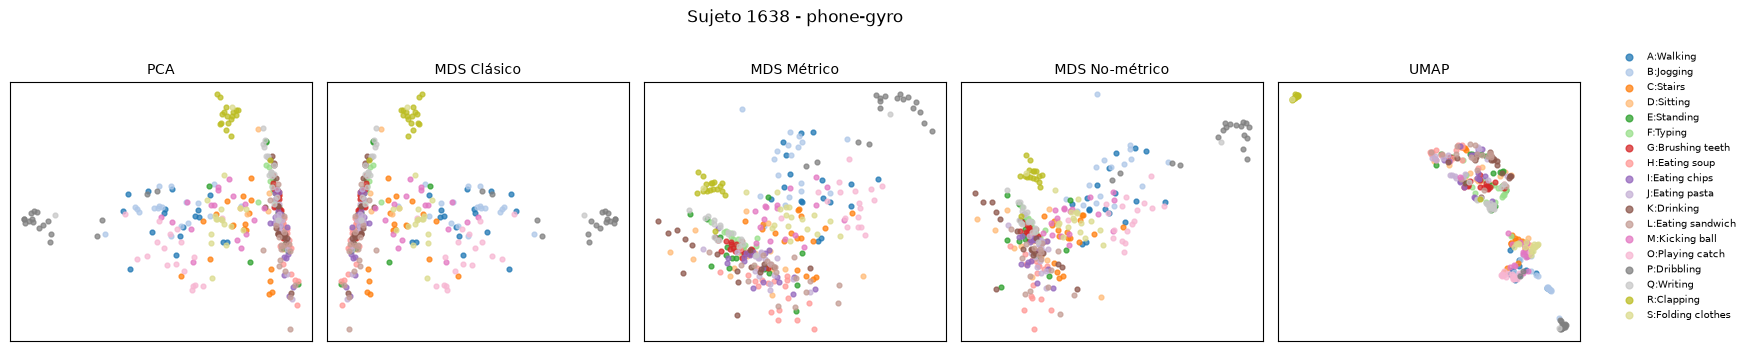

watch-accel: 803 ejemplos, 30 features, 18 actividades


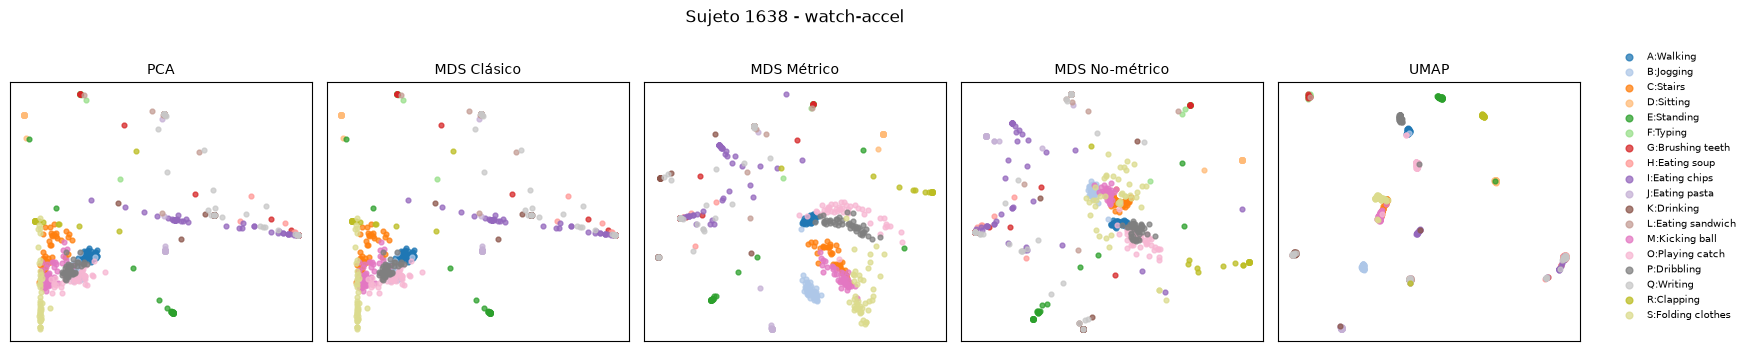

watch-gyro: 357 ejemplos, 30 features, 16 actividades


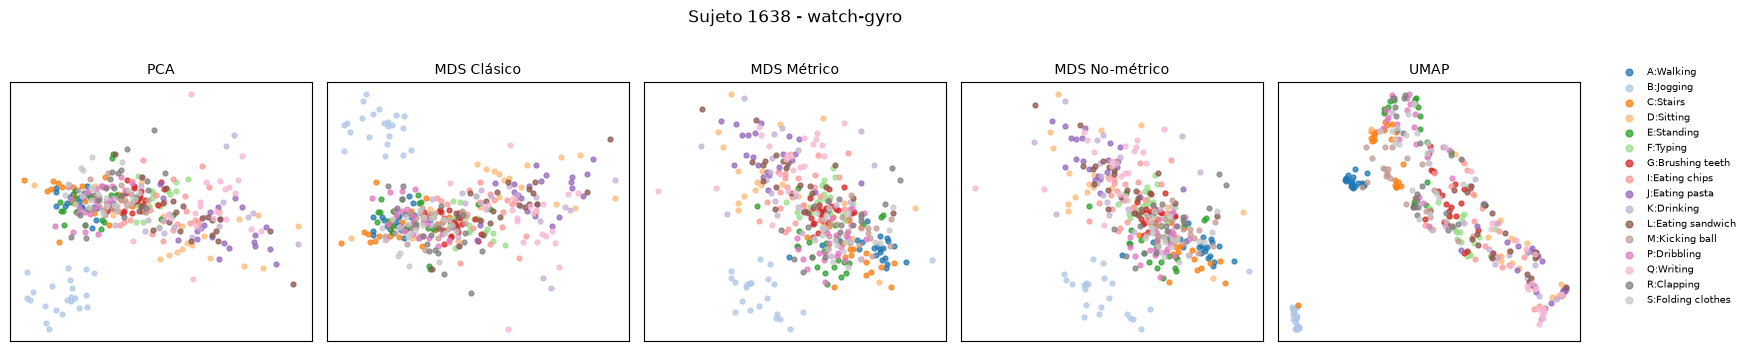

In [4]:
for sid in SUBJECTS:
    print("=" * 70)
    print(f"Sujeto {sid}")
    print("=" * 70)
    for case_name, suffix in CASES.items():
        X, y = load_sample(sid, suffix)
        print(
            f"{case_name}: {X.shape[0]} ejemplos, {X.shape[1]} features, "
            f"{len(np.unique(y))} actividades"
        )
        emb = reduce_2d(X)
        plot_embeddings(emb, y, f"Sujeto {sid} - {case_name}")


## 5. Tres sujetos unidos por sensor

Se concatenan las matrices de los tres voluntarios y se repiten las cinco proyecciones.


phone-accel: 1074 ejemplos unidos


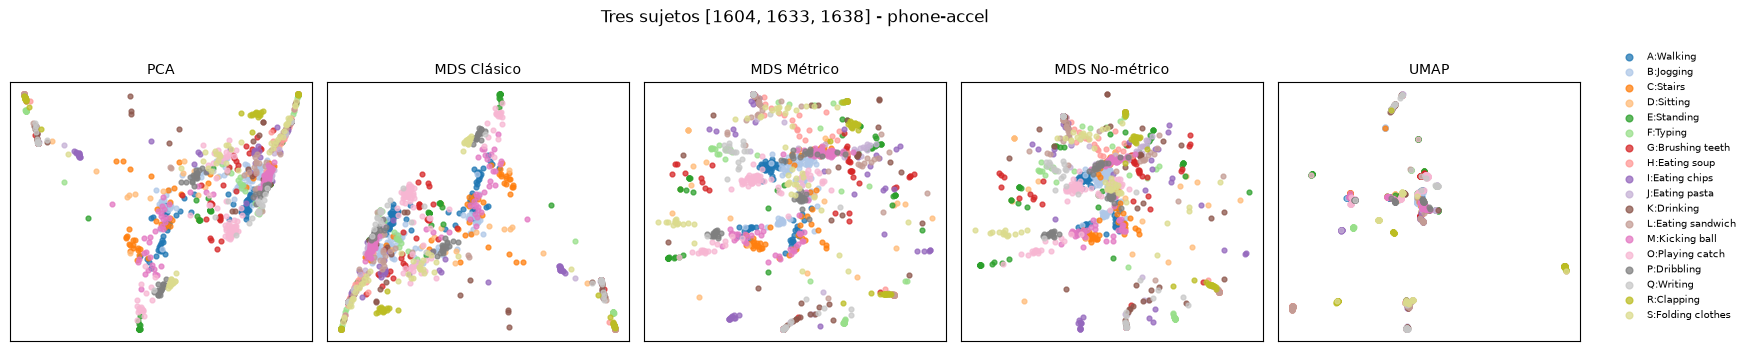

phone-gyro: 965 ejemplos unidos


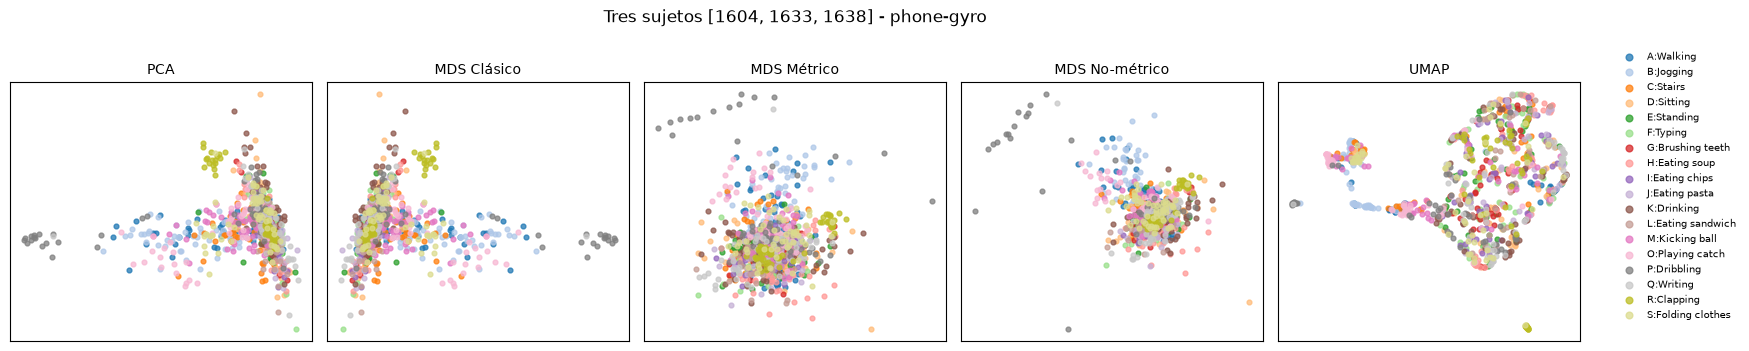

watch-accel: 1451 ejemplos unidos


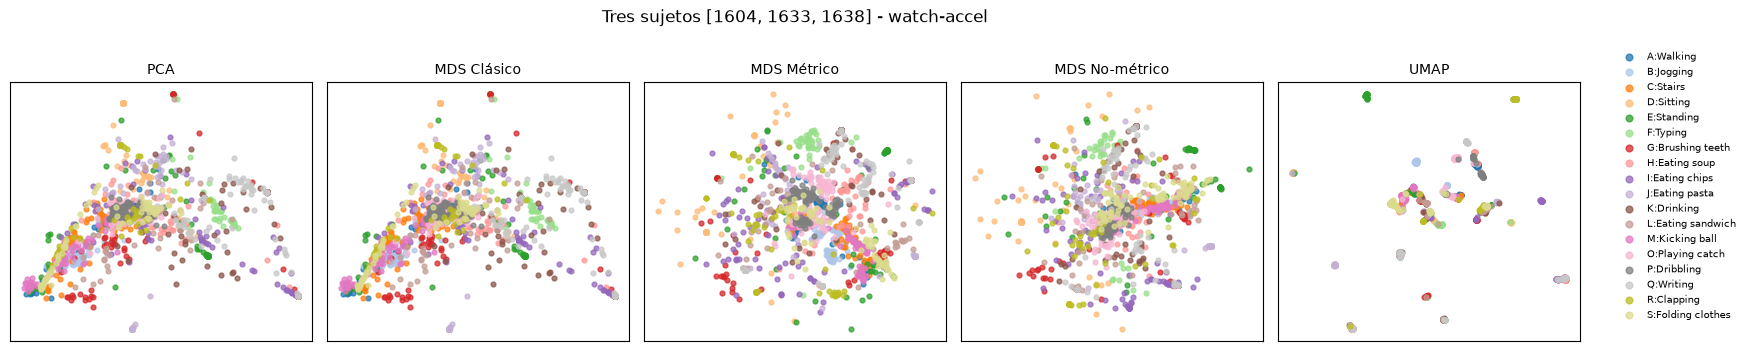

watch-gyro: 1005 ejemplos unidos


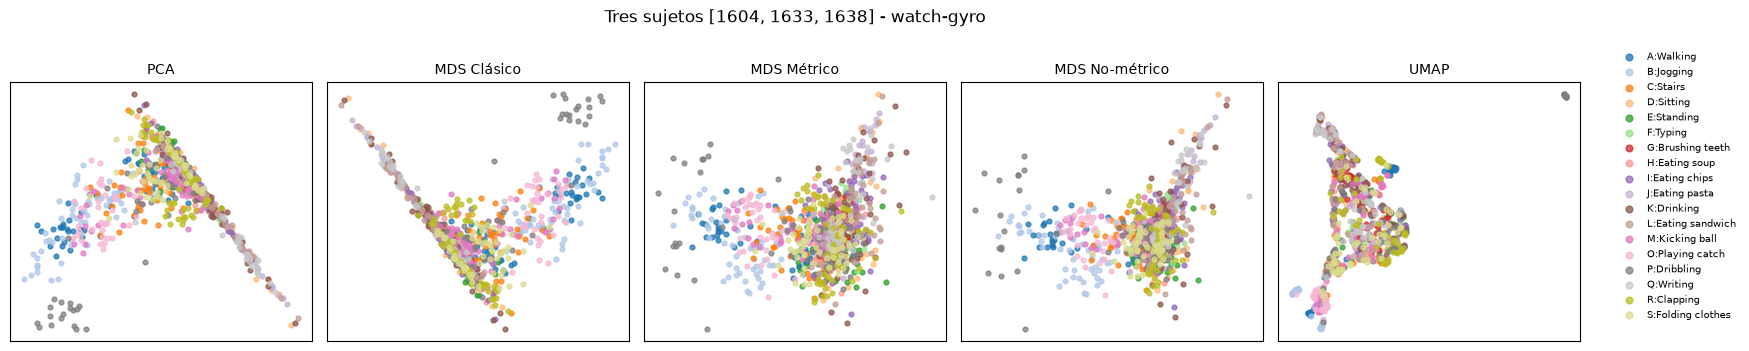

In [5]:
for case_name, suffix in CASES.items():
    Xs, ys = [], []
    for sid in SUBJECTS:
        X, y = load_sample(sid, suffix)
        Xs.append(X)
        ys.append(y)
    Xc = np.vstack(Xs)
    yc = np.concatenate(ys)
    print(f"{case_name}: {Xc.shape[0]} ejemplos unidos")
    emb = reduce_2d(Xc)
    plot_embeddings(emb, yc, f"Tres sujetos {SUBJECTS} - {case_name}")


## 6. Observaciones

Tras revisar las proyecciones (sobre todo **UMAP** y **PCA** en datos unidos):

### ¿Qué actividades se diferencian mejor en 2D?
- Actividades de **movimiento amplio o rítmico**: **Jogging (B)**, **Stairs (C)**, **Clapping (R)**, **Dribbling (P)** y **Brushing teeth (G)**.
- En **watch-accel**, también destacan posturas/estáticos como **Sitting (D)** y **Standing (E)**, y gestos de mano como **Typing (F)** o **Eating pasta (J)**.
- El acelerómetro del reloj suele separar mejor que el del teléfono porque captura mejor el movimiento de la muñeca.

### ¿Qué actividades se superponen en 2D?
- Actividades de **mano/alimentarse** con patrones similares: **Eating chips (I)**, **Eating pasta (J)**, **Eating soup (H)**, **Eating sandwich (L)**, **Drinking (K)**.
- Actividades quietas o de escritorio: **Sitting (D)**, **Typing (F)**, **Writing (Q)** (según el sensor).
- En locomoción, a veces se mezclan **Walking (A)** con **Playing catch (O)** / **Dribbling (P)**, y **Stairs (C)** con **Kicking ball (M)** o **Folding clothes (S)**.

En resumen: se separan mejor las actividades con dinámica distinta (correr, aplaudir, subir escaleras); se solapan las de manipulación fina o posturas parecidas.
